# Target-OAR Diagram Layout Template
This notebook is intended to develop and document the Target-OAR diagram layout 
template.  

## Introduction

The Target-OAR diagram layout template is intended to illustrate which OARs 
directly compete with Target structures.  
It will optionally also show opt-OAR structures generated to account for regions 
of overlap between Target and OAR structures.
Once the metrics module is further developed, the template will also display 
the percentage of overlap between the targets and OARs.

The template development process contains the following parts:
1. Create a "Principle Targets" selection filter
2. Select related OARs for each principle target
3. Sort the related OARs based on their relationship to each of the principle targets
4. Build a Bipartite format diagram layout based on the sorted OARs and principle targets
5. Add opt-OARs to the diagram layout based on the sorted OARs and principle targets

## Setup

### Imports

#### Standard Libraries

In [1]:
from typing import Dict, List, Union

from pathlib import Path
import re

from pprint import pprint
import xml.etree.ElementTree as ET
from itertools import chain


#### Public Packages

In [2]:
import pandas as pd
import xlwings as xw
import networkx as nx
from matplotlib import pyplot as plt

#### Local Modules

In [3]:
from structure_set import StructureSet

from dicom import DicomStructureFile

from structure_grouping import analyze_structure_grouping

from diagram_layout import (
    PrincipleTargetSelectorConfig,
    apply_layout_template,
    default_grouped_grid_template,
    get_layout_template,
    principle_targets_template,
    relationship_spring_template,
)

from diagram_rendering import (
    apply_crossing_heavy_label_offsets,
    render_template_diagram,
)

INFO:metrics.base:Registered calculator: minimum_margins (ContainmentMarginsCalculator)
INFO:metrics.base:Registered calculator: maximum_margin (MaximumMarginCalculator)
INFO:metrics.base:Registered calculator: minimum_distance (MinimumDistanceCalculator)


### Paths

In [4]:
base_path = Path.cwd()
dicom_path = base_path / "tests"
structure_filter_def = base_path / r"src/webapp/config/structure_filter_rules.json"

## Utility Functions

### Load the DICOM file

In [5]:
def load_grouping_table(dicom_file: DicomStructureFile,
                        apply_filter: bool = False) -> pd.DataFrame:
    '''
    Build a structure grouping table directly from a DICOM file.

    Args:
        dicom_file (DicomStructureFile): The DICOM structure file.
        apply_filter (bool): Whether to apply configured structure filtering.
            Default is False.

    Returns:
        pd.DataFrame: ROI-indexed table containing grouping hierarchy and
            placement columns.
    '''
    return analyze_structure_grouping(
        dicom_file=dicom_file,
        apply_filter=apply_filter,
    )

In [6]:
def grouping_columns_for_display(targets_df: pd.DataFrame) -> list[str]:
    '''Return grouping and placement columns that are present in a table.'''
    display_columns = [
        'Structure ID',
        'Mod',
        'DICOM Type',
        'TargetDose',
        'TargetLaterality',
        'TargetSubGroup',
        'h_group_1',
        'h_group_2',
        'v_group_1',
        'v_group_2',
        'v_group_3',
        'h_index',
        'v_index',
        'is_unique_slot',
    ]
    return [column for column in display_columns
            if column in targets_df.columns]

## Load an example H&N DICOM structure set

In [7]:
dcm_file_name = 'RS.OROP2_3_dose_levels.dcm'
dcm_file_path = dicom_path / dcm_file_name
dicom_file = DicomStructureFile(top_dir=dicom_path, file_path=dcm_file_path)
pprint(dicom_file.structure_set_info)

# Use the structure filter rules to determine which structures to load.
filter_report = dicom_file.evaluate_structure_filters()
include_structures = list(filter_report.loc[filter_report['SelectedByDefault'],
                                            'Structure ID'])

# Build the target grouping table, applying the filter to limit to Target structures.
targets_df = analyze_structure_grouping(dicom_file, apply_filter=True)


structure_set = StructureSet(dicom_structure_file=dicom_file,
                             include_structures=include_structures,
                             logging_enabled=False)

INFO:dicom:Successfully loaded DICOM dataset from RS.OROP2_3_dose_levels.dcm
INFO:dicom:Extracted 2371 contours from 52 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.OROP2_3_dose_levels.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.050 cm/pixel


{'File': WindowsPath("d:/OneDrive - Queen's University/Python/Projects/StructureRelations/tests/RS.OROP2_3_dose_levels.dcm"),
 'PatientID': 'HN_OROP2',
 'PatientLastName': 'HN_OROP',
 'PatientName': 'HN_OROP^2Dose^Levels',
 'SeriesDescription': '',
 'SeriesNumber': 'None',
 'StructureSet': 'OROP',
 'StudyID': ''}


d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: divide by zero encountered in relate
  return lib.relate(a, b, **kwargs)
d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: invalid value encountered in relate
  return lib.relate(a, b, **kwargs)


## Create a "Principle Targets" selection filter

### Apply the default principle-target filter

The default `principle_targets` template keeps one selected principle target per target group and ignores groups that do not contain a PTV.

In [8]:
principle_template = get_layout_template('principle_targets')
principle_layout = apply_layout_template(structure_set, principle_template)
principle_nodes = principle_layout.plot_nodes.copy()

principle_columns = [
    'ROI',
    'Name',
    'h_grouping',
    'h_group_1',
    'TargetType',
    'Mod',
    'TargetLaterality',
    'TargetSubGroup',
    'Physical_Volume',
    'placement_order',
]
principle_columns = [
    column for column in principle_columns if column in principle_nodes.columns
]
principle_preview = principle_nodes[principle_columns].sort_values(
    ['h_grouping', 'placement_order'],
    kind='stable',
)

group_key = 'h_group_1' if 'h_group_1' in targets_df.columns else 'h_grouping'
candidate_counts = targets_df.groupby(group_key)['Structure ID'].count().rename(
    'CandidateTargets'
 )
principle_counts = principle_nodes.groupby('h_grouping')['ROI'].count().rename(
    'PrincipleTargets'
 )
principle_group_counts = pd.concat([candidate_counts, principle_counts], axis=1).fillna(0)
principle_group_counts = principle_group_counts.astype(int)
principle_group_counts['OneSelectedPerGroup'] = (
    principle_group_counts['PrincipleTargets'] == 1
)

principle_preview.sort_index().loc[:,['Name', 'ROI']]

,Name,ROI
0,eval PTV 56,68
1,PTV 66,66
2,opt PTV 70,79


### Optional fallback mode for groups without a PTV

This fallback mode keeps one selection per group by using CTV, then GTV, when no PTV exists.

In [9]:
fallback_template = principle_targets_template(
    selector_config=PrincipleTargetSelectorConfig(
        missing_ptv_mode='fallback_to_ctv_then_gtv',
    ),
)
fallback_layout = apply_layout_template(structure_set, fallback_template)
fallback_nodes = fallback_layout.plot_nodes.copy()

default_selection = principle_nodes[['h_grouping', 'Name']].copy()
default_selection = default_selection.rename(columns={'Name': 'DefaultSelection'})
fallback_selection = fallback_nodes[['h_grouping', 'Name']].copy()
fallback_selection = fallback_selection.rename(columns={'Name': 'FallbackSelection'})

selection_comparison = default_selection.merge(
    fallback_selection,
    on='h_grouping',
    how='outer',
).sort_values('h_grouping', kind='stable')

selection_comparison

,h_grouping,DefaultSelection,FallbackSelection
0,56,eval PTV 56,eval PTV 56
1,66,PTV 66,PTV 66
2,70,opt PTV 70,opt PTV 70
3,missing,NaN,GTV


## Select related OARs for each principle target


In [10]:
selected_targets = list(principle_nodes['Name'])

oar_structures = list(
    filter_report.loc[filter_report['DICOM Type'] == 'ORGAN', 'Structure ID']
 )
oar_structures = [
    structure for structure in oar_structures
    if structure in structure_set.relationship_matrix.index
]

relations = structure_set.relationship_matrix.loc[oar_structures, selected_targets]

def get_rt_category(rel):
    return rel.relationship_type.category

relation_categories = relations.map(get_rt_category)

all_separate_idx = relation_categories.apply(
    lambda row: (row == 'Separate').all(),
    axis=1,
)
selected_oars = relation_categories.index[~all_separate_idx].tolist()

selected_oar_relations = relations.loc[selected_oars, selected_targets]
selected_oar_categories = relation_categories.loc[selected_oars, selected_targets]

selection_summary = pd.DataFrame({
    'TotalOARs': [len(oar_structures)],
    'ExcludedAllSeparate': [int(all_separate_idx.sum())],
    'SelectedOARs': [len(selected_oars)],
})

selection_summary, selected_oar_categories

(   TotalOARs  ExcludedAllSeparate  SelectedOARs
 0         17                   12             5,
 Structure_A eval PTV 56    PTV 66 opt PTV 70
 Structure_B                                 
 Larynx           Shared  Separate  Adjoining
 Mandible         Shared  Separate     Shared
 Parotid B        Shared  Separate     Shared
 Parotid L        Shared  Separate   Separate
 Parotid R        Shared  Separate     Shared)

In [11]:
selected_oars

['Larynx', 'Mandible', 'Parotid B', 'Parotid L', 'Parotid R']

In [12]:
selected_oar_categories.T

Structure_B,Larynx,Mandible,Parotid B,Parotid L,Parotid R
Structure_A,,,,,
eval PTV 56,Shared,Shared,Shared,Shared,Shared
PTV 66,Separate,Separate,Separate,Separate,Separate
opt PTV 70,Adjoining,Shared,Shared,Separate,Shared


## Sort the related OARs based on their relationship to each of the principle targets


In [13]:
def set_category_rank(category: str) -> float:
    '''Assign a numeric rank to a relationship category.'''
    category_rank = {'Shared': 1, 'Adjoining': 0.5, 'Separate': 0}
    return category_rank.get(category, 0)


In [14]:
category_rank = selected_oar_categories.T.map(set_category_rank)
category_rank

Structure_B,Larynx,Mandible,Parotid B,Parotid L,Parotid R
Structure_A,,,,,
eval PTV 56,1.0,1,1,1,1
PTV 66,0.0,0,0,0,0
opt PTV 70,0.5,1,1,0,1


In [15]:
num_targets = len(selected_targets)

if num_targets % 2 == 0:
    rank_values = [
        i
        for i in range(-(num_targets // 2), (num_targets // 2) + 1)
        if i != 0
    ]
else:
    rank_values = [
        i
        for i in range(-(num_targets // 2), (num_targets // 2) + 1)
    ]

target_rank = pd.DataFrame({
    'Name': list(category_rank.index),
    'TargetRank': rank_values,
}).set_index('Name')

target_rank

,TargetRank
Name,
eval PTV 56,-1
PTV 66,0
opt PTV 70,1


In [16]:
weighted_category_rank = category_rank.mul(
    target_rank['TargetRank'],
    axis=0,
 )

oar_rank_sum = weighted_category_rank.sum(axis=0).sort_values(ascending=False)
oar_rank_summary = pd.DataFrame({
    'WeightedRankSum': oar_rank_sum,
})

weighted_category_rank, oar_rank_summary

(Structure_B  Larynx  Mandible  Parotid B  Parotid L  Parotid R
 Structure_A                                                   
 eval PTV 56    -1.0        -1         -1         -1         -1
 PTV 66          0.0         0          0          0          0
 opt PTV 70      0.5         1          1          0          1,
              WeightedRankSum
 Structure_B                 
 Mandible                 0.0
 Parotid R                0.0
 Parotid B                0.0
 Larynx                  -0.5
 Parotid L               -1.0)

In [17]:
oar_rank_summary = oar_rank_summary.sort_values(
    by='WeightedRankSum',
    ascending=False,
 )

sorted_oars = oar_rank_summary.index.tolist()
sorted_oars

['Mandible', 'Parotid R', 'Parotid B', 'Larynx', 'Parotid L']

## Build a Bipartite format diagram layout based on the sorted OARs and principle targets


### Render the principle-target-only layout

This render uses the same grouped-grid layout engine with the principle target filter as the node-selection stage.

('principle_targets',
    ROI         Name h_grouping v_grouping  h_index  v_index
 0   68  eval PTV 56         56       eval      2.0        3
 1   66       PTV 66         66    missing      5.5        2
 2   79   opt PTV 70         70        opt      7.0        2)

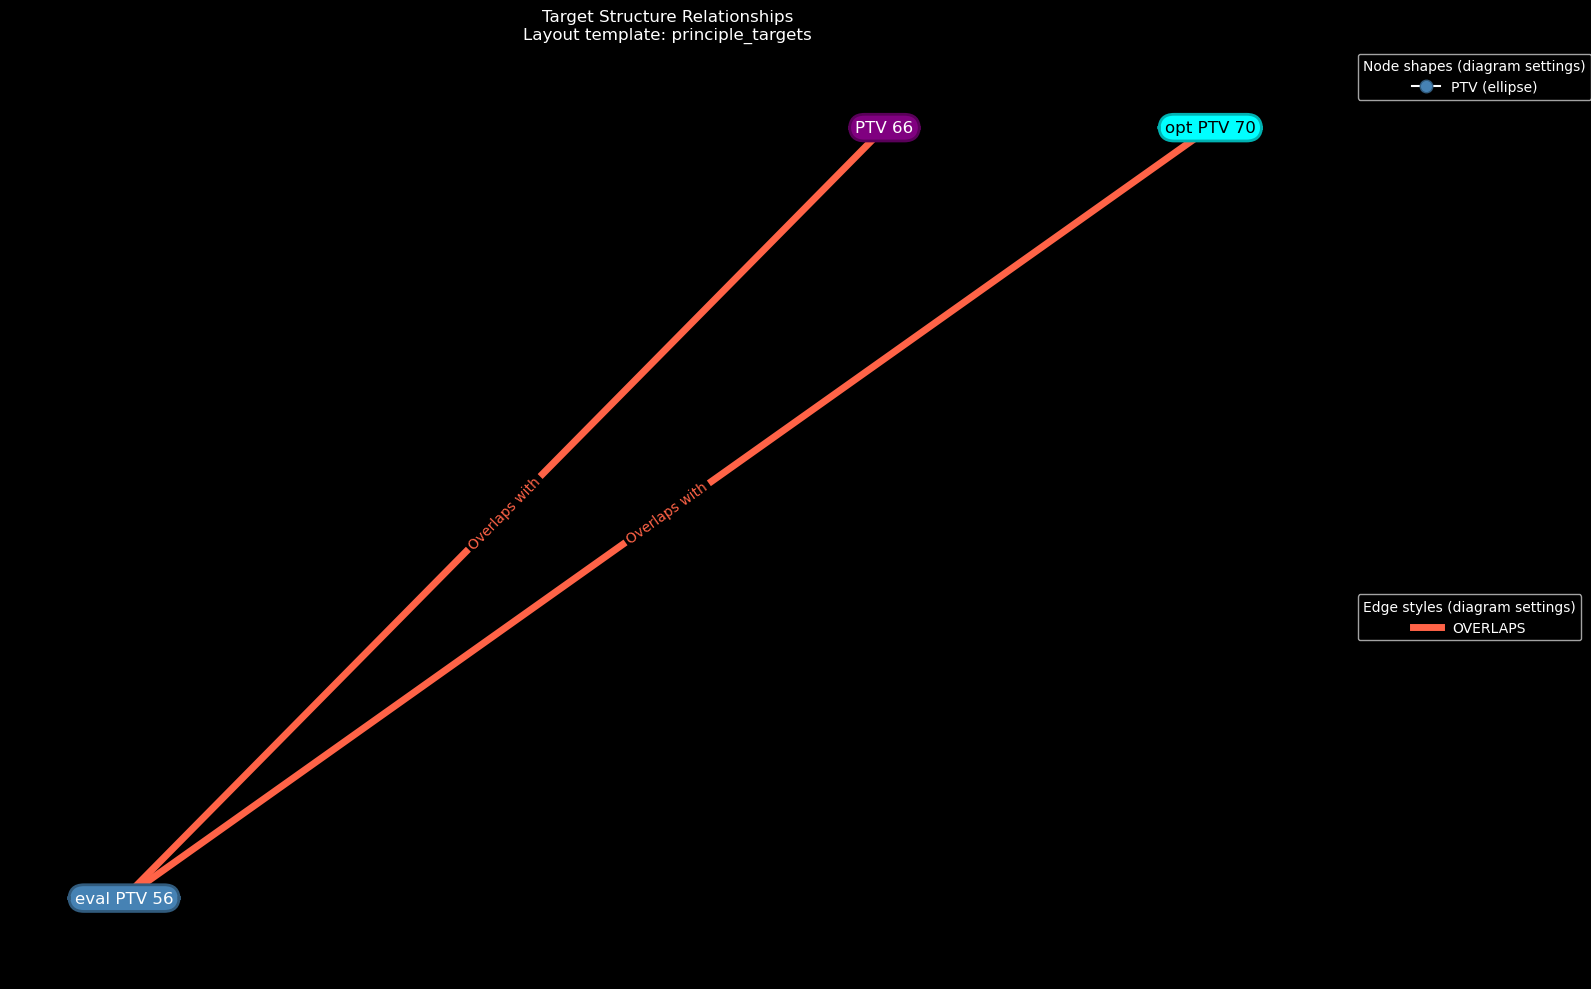

In [18]:
module_result = render_template_diagram(
    structure_set=structure_set,
    layout_template=principle_template,
    diagram_settings_path=(
        base_path / 'src' / 'webapp' / 'config' / 'diagram_settings.json'
    ),
    hide_logical_edges=True,
    show_plot=False,
)

apply_crossing_heavy_label_offsets(module_result)

render_preview_columns = [
    'ROI',
    'Name',
    'h_grouping',
    'v_grouping',
    'h_index',
    'v_index',
]
render_preview_columns = [
    column for column in render_preview_columns if column in module_result.plot_nodes.columns
]

module_result.layout_template_name, module_result.plot_nodes[render_preview_columns]

## Add opt-OARs to the diagram layout based on the sorted OARs and principle targets